# EGIT 2024: perfiles de gasto y duración del viaje

La base consolidada reúne personas observadas por trimestre. La muestra de trabajo conserva registros con gasto informado y desglose positivo; después se excluyen atípicos de gasto total y duración mediante IQR.

**¿Qué se analiza?** La composición del gasto entre nueve rubros, el nivel del gasto total y la duración. Edad, ingreso del hogar, sexo y ciudad pueden aparecer en la exploración, pero **no forman parte de las 11 variables de k-means**.

**No se aplica reducción de dimensionalidad.** Se seleccionan y construyen 11 variables y se estandarizan: la matriz conserva 11 columnas. El scatter muestra solamente dos proporciones del gasto; el mapa de perfiles permite comparar los centroides en las 11 variables.

## Punto 0: Carga de datos
Se leen los 36 CSV extraídos, separados por `|`, sin cargar nuevamente los TXT ni los ZIP. Se conservan códigos como texto y ceros iniciales: tener dígitos no convierte una variable en cuantitativa.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import re
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RAIZ = Path.cwd()
assert (RAIZ / "Bases de datos").is_dir(), "Ejecuta desde K_means."
SALIDA = RAIZ / "Resultados"
SALIDA.mkdir(exist_ok=True)
carpetas = {
    1: "Base de datos-EGIT-Base Anonimizada-I trim2024",
    2: "Base de datos-EGIT-Base Anonimizada-II trim2024",
    3: "III Trim 2024",
    4: "Base de datos-EGIT-Base Anonimizada-IV trim2024",
}
modulos = ["CARACTERISTICAS_GENERALES", "EDUCACION", "FUERZA_DE_TRABAJO",
           "COMPLEMENTARIAS", "TURISMO", "EXCURSIONISMO", "HOGAR",
           "VIVIENDA", "VIVIENDA_USO_RECREATIVO"]
tablas = {}
inventario = []
for trimestre, carpeta in carpetas.items():
    for modulo in modulos:
        ruta = RAIZ / "Bases de datos" / carpeta / (modulo + ".csv")
        tabla = pd.read_csv(ruta, sep="|", dtype="string", encoding="utf-8",
                            keep_default_na=False, na_values=[""])
        assert tabla.columns.is_unique
        tablas[trimestre, modulo] = tabla
        inventario.append({
            "trimestre": trimestre, "modulo": modulo,
            "filas": len(tabla), "columnas": tabla.shape[1],
            "duplicados_exactos": int(tabla.duplicated().sum()),
            "archivo": str(ruta.relative_to(RAIZ)),
        })
inventario = pd.DataFrame(inventario)
assert len(inventario) == 36
display(inventario)

,trimestre,modulo,filas,columnas,duplicados_exactos,archivo
0,1,CARACTERISTICAS_GENERALES,31185,12,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
1,1,EDUCACION,30291,12,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
2,1,FUERZA_DE_TRABAJO,27401,17,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
3,1,COMPLEMENTARIAS,27401,31,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
4,1,TURISMO,27401,92,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
5,1,EXCURSIONISMO,27401,49,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
6,1,HOGAR,10746,23,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
7,1,VIVIENDA,10635,13,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
8,1,VIVIENDA_USO_RECREATIVO,171,13,0,Bases de datos/Base de datos-EGIT-Base Anonimi...
9,2,CARACTERISTICAS_GENERALES,30542,12,0,Bases de datos/Base de datos-EGIT-Base Anonimi...


## Punto 1: Entendimiento y exploración inicial
### 1.1 Dimensiones, tipos, faltantes y esquemas
Son conteos de registros, no estimaciones de población ponderadas por `Fex_c`.

In [2]:
calidad_origen = []
esquemas = []
for (trimestre, modulo), tabla in tablas.items():
    calidad_origen.append(pd.DataFrame({
        "trimestre": trimestre, "modulo": modulo, "variable": tabla.columns,
        "tipo_lectura": tabla.dtypes.astype(str).values,
        "faltantes": tabla.isna().sum().values,
        "porcentaje_faltante": (tabla.isna().mean() * 100).values,
        "valores_distintos": tabla.nunique().values,
    }))
    referencia = tablas[1, modulo].columns
    esquemas.append({
        "trimestre": trimestre, "modulo": modulo,
        "mismo_esquema_que_T1": tabla.columns.equals(referencia),
        "columnas_nuevas": ", ".join(tabla.columns.difference(referencia)),
        "columnas_ausentes": ", ".join(referencia.difference(tabla.columns)),
    })
calidad_origen = pd.concat(calidad_origen, ignore_index=True)
esquemas = pd.DataFrame(esquemas)
display(esquemas)
display(calidad_origen.sort_values("porcentaje_faltante", ascending=False).head(25))

,trimestre,modulo,mismo_esquema_que_T1,columnas_nuevas,columnas_ausentes
0,1,CARACTERISTICAS_GENERALES,True,,
1,1,EDUCACION,True,,
2,1,FUERZA_DE_TRABAJO,True,,
3,1,COMPLEMENTARIAS,True,,
4,1,TURISMO,True,,
5,1,EXCURSIONISMO,True,,
6,1,HOGAR,True,,
7,1,VIVIENDA,True,,
8,1,VIVIENDA_USO_RECREATIVO,True,,
9,2,CARACTERISTICAS_GENERALES,True,,


,trimestre,modulo,variable,tipo_lectura,faltantes,porcentaje_faltante,valores_distintos
736,3,EXCURSIONISMO,P7587S8A3,string,26962,100.000000,0
721,3,EXCURSIONISMO,P7587S4A3,string,26962,100.000000,0
998,4,EXCURSIONISMO,P7587S8A3,string,26017,100.000000,0
474,2,EXCURSIONISMO,P7587S8A3,string,26869,100.000000,0
463,2,EXCURSIONISMO,P7587S5A3,string,26869,100.000000,0
672,3,TURISMO,P7581S5A3,string,26962,100.000000,0
422,2,TURISMO,P7581S8A3,string,26869,100.000000,0
471,2,EXCURSIONISMO,P7587S7A3,string,26869,100.000000,0
459,2,EXCURSIONISMO,P7587S4A3,string,26869,100.000000,0
424,2,TURISMO,P7581S11A2,string,26869,100.000000,0


### 1.2 Alcance de la base

Cada fila representa una persona observada en un trimestre, con información de su hogar y vivienda. Los códigos y categorías se consultan en el [diccionario EGIT 2024](https://microdatos.dane.gov.co/index.php/catalog/864/data-dictionary).


## Punto 2: Calidad de datos y construcción de la base
### 2.0 Estado inicial: granularidad y duplicados
Módulos personales: `Directorio + Secuencia_p + Orden`. Hogar: `llave_hogar`. Vivienda: `Directorio`. Se añade el trimestre a la llave final.

En vivienda recreativa, se conserva cada registro dentro del hogar en columnas separadas. Su `Orden` no se cruza con el orden de una persona. No se suman ni promedian estos registros.

In [3]:
llave_persona = ["Directorio", "Secuencia_p", "Orden"]
llaves = {modulo: llave_persona for modulo in modulos}
llaves["HOGAR"] = ["llave_hogar"]
llaves["VIVIENDA"] = ["Directorio"]
llaves["VIVIENDA_USO_RECREATIVO"] = ["llave_hogar", "Orden"]
control_llaves = []
for (trimestre, modulo), tabla in tablas.items():
    clave = llaves[modulo]
    control_llaves.append({
        "trimestre": trimestre, "modulo": modulo, "llave": " + ".join(clave),
        "filas_sin_llave": int(tabla[clave].isna().any(axis=1).sum()),
        "duplicados_por_llave": int(tabla.duplicated(clave).sum()),
        "duplicados_exactos": int(tabla.duplicated().sum()),
    })
control_llaves = pd.DataFrame(control_llaves)
display(control_llaves)
assert control_llaves["filas_sin_llave"].sum() == 0
assert control_llaves["duplicados_por_llave"].sum() == 0, "Revisar llaves repetidas antes de cruzar."

,trimestre,modulo,llave,filas_sin_llave,duplicados_por_llave,duplicados_exactos
0,1,CARACTERISTICAS_GENERALES,Directorio + Secuencia_p + Orden,0,0,0
1,1,EDUCACION,Directorio + Secuencia_p + Orden,0,0,0
2,1,FUERZA_DE_TRABAJO,Directorio + Secuencia_p + Orden,0,0,0
3,1,COMPLEMENTARIAS,Directorio + Secuencia_p + Orden,0,0,0
4,1,TURISMO,Directorio + Secuencia_p + Orden,0,0,0
5,1,EXCURSIONISMO,Directorio + Secuencia_p + Orden,0,0,0
6,1,HOGAR,llave_hogar,0,0,0
7,1,VIVIENDA,Directorio,0,0,0
8,1,VIVIENDA_USO_RECREATIVO,llave_hogar + Orden,0,0,0
9,2,CARACTERISTICAS_GENERALES,Directorio + Secuencia_p + Orden,0,0,0


### 2.1 Ensamblaje por trimestre
Se conserva a todas las personas de características generales. Los prefijos indican procedencia y evitan sobrescribir columnas. Los indicadores `presente__MODULO` distinguen la ausencia de un registro completo de un vacío dentro del registro; **no certifican que una pregunta no aplique**.

Cada cruce comprueba unicidad, registros sin enlace y conservación de filas. Vivienda recreativa se reorganiza con `set_index().unstack()`, operaciones presentes en el parcial, sin agregación.

In [4]:
bases_trimestrales = []
control_cruces = []
procedencia = []
for trimestre in carpetas:
    base = tablas[trimestre, "CARACTERISTICAS_GENERALES"].copy()
    if trimestre == 1:
        procedencia.extend({
            "columna": c, "modulo": "CARACTERISTICAS_GENERALES", "variable_original": c
        } for c in base.columns)
    for modulo in modulos[1:]:
        fuente = tablas[trimestre, modulo].copy()
        if modulo == "VIVIENDA_USO_RECREATIVO":
            clave = ["llave_hogar"]
            fuente["presente"] = "1"
            derecha = fuente.set_index(["llave_hogar", "Orden"]).unstack("Orden")
            nombres = {
                par: modulo + "__" + par[0] + "__registro_" + str(par[1])
                for par in derecha.columns
            }
            procedencia.extend({
                "columna": nombre, "modulo": modulo, "variable_original": par[0]
            } for par, nombre in nombres.items())
            derecha.columns = [nombres[par] for par in derecha.columns]
            derecha = derecha.reset_index()
        else:
            clave = llaves[modulo]
            nombres = {c: modulo + "__" + c for c in fuente.columns if c not in clave}
            procedencia.extend({
                "columna": nombre, "modulo": modulo, "variable_original": original
            } for original, nombre in nombres.items())
            derecha = fuente.rename(columns=nombres)
        cobertura = derecha[clave].merge(
            base[clave].drop_duplicates(), on=clave, how="left",
            validate="one_to_one", indicator=True
        )
        huerfanas = int((cobertura["_merge"] == "left_only").sum())
        assert huerfanas == 0, f"Registros sin enlace: T{trimestre} {modulo}"
        indicador = "presente__" + modulo
        derecha[indicador] = True
        filas_antes = len(base)
        base = base.merge(derecha, on=clave, how="left", validate="many_to_one")
        base[indicador] = base[indicador].eq(True)
        assert len(base) == filas_antes
        control_cruces.append({
            "trimestre": trimestre, "modulo": modulo,
            "filas_antes": filas_antes, "filas_despues": len(base),
            "personas_sin_registro_modulo": int((~base[indicador]).sum()),
            "registros_huerfanos": huerfanas,
        })
    base["trimestre"] = trimestre
    base["anio"] = 2024
    bases_trimestrales.append(base)
df_consolidado = pd.concat(bases_trimestrales, ignore_index=True)
control_cruces = pd.DataFrame(control_cruces)
procedencia = pd.DataFrame(procedencia).drop_duplicates().reset_index(drop=True)
llave_final = ["trimestre"] + llave_persona
assert not df_consolidado.duplicated(llave_final).any()
assert len(df_consolidado) == inventario.loc[
    inventario["modulo"] == "CARACTERISTICAS_GENERALES", "filas"
].sum()
display(control_cruces)
display(df_consolidado.groupby("trimestre").size().rename("personas").to_frame())
print("Dimensión consolidada:", df_consolidado.shape)

,trimestre,modulo,filas_antes,filas_despues,personas_sin_registro_modulo,registros_huerfanos
0,1,EDUCACION,31185,31185,894,0
1,1,FUERZA_DE_TRABAJO,31185,31185,3784,0
2,1,COMPLEMENTARIAS,31185,31185,3784,0
3,1,TURISMO,31185,31185,3784,0
4,1,EXCURSIONISMO,31185,31185,3784,0
5,1,HOGAR,31185,31185,0,0
6,1,VIVIENDA,31185,31185,0,0
7,1,VIVIENDA_USO_RECREATIVO,31185,31185,30767,0
8,2,EDUCACION,30542,30542,886,0
9,2,FUERZA_DE_TRABAJO,30542,30542,3673,0


,personas
trimestre,
1,31185
2,30542
3,30740
4,29512


Dimensión consolidada: (121979, 278)


### 2.2 Diagnóstico de la base consolidada
Dos personas con las mismas respuestas no son necesariamente duplicados. Los controles conservan identificadores; ninguna alerta elimina columnas o filas automáticamente.

In [5]:
display(pd.DataFrame({
    "control": ["Duplicados exactos", "Duplicados persona-trimestre"],
    "cantidad": [df_consolidado.duplicated().sum(),
                 df_consolidado.duplicated(llave_final).sum()],
}))
calidad_consolidada = pd.DataFrame({
    "tipo": df_consolidado.dtypes.astype(str),
    "faltantes": df_consolidado.isna().sum(),
    "porcentaje_faltante": df_consolidado.isna().mean() * 100,
    "valores_distintos": df_consolidado.nunique(),
})
display(calidad_consolidada.sort_values("porcentaje_faltante", ascending=False).head(30))
display(calidad_consolidada.loc[calidad_consolidada["valores_distintos"] <= 1])

,control,cantidad
0,Duplicados exactos,0
1,Duplicados persona-trimestre,0


,tipo,faltantes,porcentaje_faltante,valores_distintos
EXCURSIONISMO__P7587S8A3,string,121979,100.000000,0
VIVIENDA_USO_RECREATIVO__P38S3A1__registro_3,string,121979,100.000000,0
TURISMO__P7581S11A2,string,121979,100.000000,0
EXCURSIONISMO__P7587S4A3,string,121979,100.000000,0
EXCURSIONISMO__P7587S7A3,string,121978,99.999180,1
EXCURSIONISMO__P7587S2A3,string,121973,99.995081,6
TURISMO__P7581S8A3,string,121972,99.994261,4
TURISMO__P7581S5A3,string,121971,99.993441,5
VIVIENDA_USO_RECREATIVO__P38S2A1__registro_3,string,121970,99.992622,2
EXCURSIONISMO__P7587S5A3,string,121969,99.991802,7


,tipo,faltantes,porcentaje_faltante,valores_distintos
TURISMO__P7581S11A2,string,121979,100.000000,0
EXCURSIONISMO__P7587S4A3,string,121979,100.000000,0
EXCURSIONISMO__P7587S7A3,string,121978,99.999180,1
EXCURSIONISMO__P7587S8A3,string,121979,100.000000,0
HOGAR__Secuencia_p,string,0,0.000000,1
presente__HOGAR,bool,0,0.000000,1
VIVIENDA__Secuencia_p,string,0,0.000000,1
VIVIENDA__Secuencia_encuesta,string,0,0.000000,1
VIVIENDA__Orden,string,0,0.000000,1
presente__VIVIENDA,bool,0,0.000000,1


In [6]:
TECNICAS_REDUNDANTES = [
    c for c in df_consolidado.columns
    if re.search(r"__(Secuencia_encuesta|Fex_c|llave_hogar|Directorio|"
                 r"Secuencia_p|Orden)(__registro_\d+)?$", c)
    or c.startswith("presente__") or "__presente__" in c
]

RENOMBRAR = {
    "Fex_c": "fex_trim",
    "VIVIENDA__area": "ciudad",
    "P6020": "sexo",
    "P6040": "edad",
    "P6050": "parentesco_jefe",
    "EDUCACION__P6170": "asiste_estudio",
    "EDUCACION__P6210": "nivel_educativo",
    "FUERZA_DE_TRABAJO__P6240": "actividad_principal",
    "HOGAR__P36": "hogar_viv_recreativa",
    "HOGAR__P545": "fuente_ingreso_principal",
    "HOGAR__P547": "ingreso_mensual_hogar",
    "TURISMO__P7570": "viajo_pernoctando",
    "TURISMO__P7571S1": "viaje_dentro_pais",
    "TURISMO__P7571S2": "viaje_fuera_pais",
    "TURISMO__P7573S1": "destino_depto",
    "TURISMO__P7573S2": "destino_municipio",
    "TURISMO__P7579": "motivo_no_viajar",
    "TURISMO__P7580": "motivo_viaje",
    "TURISMO__P7580S1": "viaje_con_quien",
    "TURISMO__P549": "fecha_inicio_viaje",
    "TURISMO__P549S1": "fecha_fin_viaje",
    "TURISMO__P15001": "reserva_por_app",
    "TURISMO__P7575": "transporte_principal",
    "TURISMO__P7576": "pago_paquete",
    "TURISMO__P7576S2": "paquete_n_personas",
    "TURISMO__P7576S3": "paquete_monto",
    "TURISMO__P7578": "gasto_total_viaje",
}
# alojamiento: S{n} = tipo usado, S{n}A1 = noches. El S7 usa A2, no A1.
for s in [1, 2, 3, 4, 5, 8, 10]:
    RENOMBRAR[f"TURISMO__P7574S{s}"] = f"aloj{s:02d}_uso"
    RENOMBRAR[f"TURISMO__P7574S{s}A1"] = f"aloj{s:02d}_noches"
RENOMBRAR["TURISMO__P7574S7"] = "aloj07_uso"
RENOMBRAR["TURISMO__P7574S7A2"] = "aloj07_noches"

# rubros: S{n} = ¿gastó?, A1 = monto, A2 = nº personas, A3 = submonto.
# El S11 no tiene A3.
for r in [1, 3, 4, 5, 6, 7, 8, 9, 10, 11]:
    RENOMBRAR[f"TURISMO__P7581S{r}"] = f"rubro{r:02d}_gasto_si"
    RENOMBRAR[f"TURISMO__P7581S{r}A1"] = f"rubro{r:02d}_monto"
    RENOMBRAR[f"TURISMO__P7581S{r}A2"] = f"rubro{r:02d}_n_personas"
    if r != 11:
        RENOMBRAR[f"TURISMO__P7581S{r}A3"] = f"rubro{r:02d}_monto_alt"

assert set(RENOMBRAR) <= set(df_consolidado.columns)
df_consolidado = (df_consolidado
                  .drop(columns=TECNICAS_REDUNDANTES)
                  .rename(columns=RENOMBRAR))
procedencia["columna"] = procedencia["columna"].replace(RENOMBRAR)

print("Técnicas eliminadas:", len(TECNICAS_REDUNDANTES))
print("Renombradas:", len(RENOMBRAR), "| Dimensión:", df_consolidado.shape)

Técnicas eliminadas: 47
Renombradas: 82 | Dimensión: (121979, 231)


In [7]:
def diagnostico(df, columnas, aplica):
    sub = df.loc[aplica, columnas]
    return pd.DataFrame({
        "n_aplica": len(sub),
        "no_nulos": sub.notna().sum(),
        "pct_faltante": (100 * sub.isna().mean()).round(2),
        "n_valores": sub.nunique(dropna=True),
    }).reset_index(names="columna").sort_values("pct_faltante")

es_viajero = df_consolidado["gasto_total_viaje"].notna()
cols_tur = [c for c in df_consolidado.columns
            if c.startswith(("rubro", "aloj"))
            or c in ("gasto_total_viaje", "transporte_principal", "motivo_viaje",
                     "pago_paquete", "fecha_inicio_viaje", "destino_depto")]

print("Viajeros con detalle:", int(es_viajero.sum()))
display(diagnostico(df_consolidado, cols_tur, es_viajero))

Viajeros con detalle: 6762


,columna,n_aplica,no_nulos,pct_faltante,n_valores
0,motivo_viaje,6762,6762,0.00,9
1,destino_depto,6762,6762,0.00,32
2,fecha_inicio_viaje,6762,6762,0.00,383
3,aloj01_uso,6762,6762,0.00,2
5,aloj05_uso,6762,6762,0.00,2
...,...,...,...,...,...
49,rubro06_monto_alt,6762,25,99.63,10
37,rubro03_monto_alt,6762,24,99.65,13
45,rubro05_monto_alt,6762,8,99.88,5
57,rubro08_monto_alt,6762,7,99.90,4


### 2.3 Selección, corrección de tipos y eliminación de filas

Se conservan las listas actuales de variables y exclusiones. Las cantidades se convierten a números y los códigos se mantienen como categorías. Se seleccionan registros con gasto total informado.

In [8]:
RUBROS = [1, 3, 4, 5, 6, 7, 8, 9, 10]   # el 11 se descarta: 27 montos en todo 2024
ALOJ = [1, 2, 3, 4, 5, 7, 8, 10]

columnas_descartar = (
    [c for c in df_consolidado.columns
     if c.startswith(("EXCURSIONISMO__", "COMPLEMENTARIAS__",
                      "VIVIENDA_USO_RECREATIVO__"))]
    + [c for c in df_consolidado.columns if c.endswith("_monto_alt")]
    + [c for c in df_consolidado.columns if c.startswith("rubro11_")]
    + ["motivo_no_viajar", "destino_municipio", "TURISMO__P7573S3",
       "TURISMO__P7571S1A1", "TURISMO__P7571S1A2", "TURISMO__P7571S1A3",
       "TURISMO__P7571S2A1", "TURISMO__P7580S3"]
)
columnas_numericas = (
    ["edad", "ingreso_mensual_hogar", "gasto_total_viaje",
     "paquete_monto", "paquete_n_personas", "fex_trim"]
    + [f"rubro{r:02d}_monto" for r in RUBROS]
    + [f"rubro{r:02d}_n_personas" for r in RUBROS]
    + [f"aloj{a:02d}_noches" for a in ALOJ]
)
columnas_categoricas = [
    "ciudad", "sexo", "nivel_educativo", "actividad_principal",
    "hogar_viv_recreativa", "fuente_ingreso_principal", "motivo_viaje",
    "viaje_con_quien", "transporte_principal", "pago_paquete",
    "reserva_por_app", "destino_depto",
] + [f"rubro{r:02d}_gasto_si" for r in RUBROS] + [f"aloj{a:02d}_uso" for a in ALOJ]

reemplazos = {}
columnas_exigir_dato = ["gasto_total_viaje"]

assert not set(columnas_descartar) & set(llave_final)
assert not set(columnas_numericas) & set(columnas_categoricas)
assert set(columnas_descartar + columnas_numericas + columnas_categoricas
           + columnas_exigir_dato + list(reemplazos)) <= set(df_consolidado.columns)
df_trabajo = df_consolidado.drop(columns=columnas_descartar).copy()
df_trabajo = df_trabajo.replace(reemplazos)
conversiones = []
for columna in columnas_numericas:
    convertida = pd.to_numeric(df_trabajo[columna], errors="coerce")
    invalidos = df_trabajo[columna].notna() & convertida.isna()
    conversiones.append({"columna": columna, "no_convertibles": int(invalidos.sum())})
    assert not invalidos.any(), f"Revisa los valores no convertibles de {columna}."
    df_trabajo[columna] = convertida.astype(float)
for columna in columnas_categoricas:
    df_trabajo[columna] = df_trabajo[columna].astype("category")
if columnas_exigir_dato:
    df_trabajo = df_trabajo.dropna(subset=columnas_exigir_dato)
display(pd.DataFrame(conversiones, columns=["columna", "no_convertibles"]))
print("Filas retiradas:", len(df_consolidado) - len(df_trabajo))

,columna,no_convertibles
0,edad,0
1,ingreso_mensual_hogar,0
2,gasto_total_viaje,0
3,paquete_monto,0
4,paquete_n_personas,0
5,fex_trim,0
6,rubro01_monto,0
7,rubro03_monto,0
8,rubro04_monto,0
9,rubro05_monto,0


Filas retiradas: 115217


### 2.4 Tratamiento de faltantes: imputación con cero

Para este ejercicio se rellenan con **0** los montos faltantes de los nueve rubros, las noches por alojamiento y el monto del paquete. Se conserva la regla actual, sin excluir registros por esos vacíos. La tabla muestra cuántos valores se reemplazan por columna.

**Supuesto y limitación:** se trata un monto desconocido como si fuera cero, incluso cuando no se conoce la respuesta sobre el gasto. Esto puede subestimar montos y modificar las proporciones y los clusters. Es una simplificación del ejercicio, no una comprobación de ausencia de gasto ni de calidad de la imputación.

Un faltante no convierte una variable cuantitativa en cualitativa. Los indicadores Sí/No/No responde no entran como variables al modelo; solo se utilizan las 11 cantidades construidas. El método final es **K-Means**, no KNN.

**Control adicional:** existen montos de gasto total iguales a 98 y 99. La documentación de EGIT 2022 los identifica como códigos de no respuesta, pero la ficha de 2024 consultada no lo aclara. Se mantienen sin recodificar hasta confirmar la convención de 2024; pueden afectar el logaritmo del gasto y los grupos. [EGIT 2022](https://microdatos.dane.gov.co/index.php/catalog/766/variable/F25/V774?name=P7578) · [Ficha 2024](https://microdatos.dane.gov.co/index.php/catalog/864/variable/F17/V567?name=P7578).


In [9]:
todos = pd.Series(True, index=df_trabajo.index)

reglas_imputacion = (
    [{"columna": f"rubro{r:02d}_monto", "aplica": todos,
      "metodo": "valor", "valor": 0.0} for r in RUBROS]
    + [{"columna": f"aloj{a:02d}_noches", "aplica": todos,
        "metodo": "valor", "valor": 0.0} for a in ALOJ]
    + [{"columna": "paquete_monto", "aplica": todos,
        "metodo": "valor", "valor": 0.0}]
)
registro_imputacion = []
for regla in reglas_imputacion:
    columna = regla["columna"]
    aplica = regla["aplica"]
    assert isinstance(aplica, pd.Series) and aplica.index.equals(df_trabajo.index)
    assert pd.api.types.is_bool_dtype(aplica) and not aplica.isna().any()
    antes = int(df_trabajo.loc[aplica, columna].isna().sum())
    if regla["metodo"] == "media":
        assert columna in columnas_numericas
        valor = df_trabajo.loc[aplica, columna].mean()
    else:
        assert regla["metodo"] == "valor"
        valor = regla["valor"]
    assert pd.notna(valor), "Valor de imputación no válido."
    df_trabajo.loc[aplica, columna] = df_trabajo.loc[aplica, columna].fillna(valor)
    despues = int(df_trabajo.loc[aplica, columna].isna().sum())
    registro_imputacion.append({
        "columna": columna, "metodo": regla["metodo"], "valor": valor,
        "imputados": antes - despues, "faltantes_aplicables": despues,
    })
registro_imputacion = pd.DataFrame(registro_imputacion, columns=[
    "columna", "metodo", "valor", "imputados", "faltantes_aplicables"
])
display(registro_imputacion)

,columna,metodo,valor,imputados,faltantes_aplicables
0,rubro01_monto,valor,0.0,5383,0
1,rubro03_monto,valor,0.0,5491,0
2,rubro04_monto,valor,0.0,2621,0
3,rubro05_monto,valor,0.0,5891,0
4,rubro06_monto,valor,0.0,5949,0
5,rubro07_monto,valor,0.0,5754,0
6,rubro08_monto,valor,0.0,6222,0
7,rubro09_monto,valor,0.0,6030,0
8,rubro10_monto,valor,0.0,2987,0
9,aloj01_noches,valor,0.0,6589,0


In [10]:
df_trabajo["duracion_dias"] = (
    pd.to_datetime(df_trabajo["fecha_fin_viaje"], errors="coerce")
    - pd.to_datetime(df_trabajo["fecha_inicio_viaje"], errors="coerce")
).dt.days
df_trabajo["log_gasto_total"] = np.log1p(df_trabajo["gasto_total_viaje"])

COLS_RUBRO = [f"rubro{r:02d}_monto" for r in RUBROS]
df_trabajo["suma_rubros"] = df_trabajo[COLS_RUBRO].sum(axis=1)
df_trabajo["coherencia"] = df_trabajo["suma_rubros"] / df_trabajo["gasto_total_viaje"]

print("Sin desglose (suma_rubros == 0):", int((df_trabajo["suma_rubros"] == 0).sum()))
display(df_trabajo.loc[df_trabajo["suma_rubros"] > 0, "coherencia"]
        .describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

# los que no tienen desglose no sirven para composición
df_trabajo = df_trabajo.loc[df_trabajo["suma_rubros"] > 0].copy()

for r in RUBROS:
    df_trabajo[f"share_rubro{r:02d}"] = (
        df_trabajo[f"rubro{r:02d}_monto"] / df_trabajo["suma_rubros"])

# para que el Punto 3 analice las variables que realmente se van a usar
columnas_numericas += (["duracion_dias", "log_gasto_total", "suma_rubros"]
                       + [f"share_rubro{r:02d}" for r in RUBROS])

print("Base para clustering:", df_trabajo.shape)

Sin desglose (suma_rubros == 0): 2033


count    4729.000
mean        0.953
std         0.272
min         0.000
5%          0.378
25%         1.000
50%         1.000
75%         1.000
95%         1.000
max         5.000
Name: coherencia, dtype: float64

Base para clustering: (4729, 135)


### 2.5 Resumen de la preparación

Se conservan registros con gasto total informado, se imputan con cero los campos del apartado 2.4 y se exige suma positiva del desglose utilizado. Se construyen duración, logaritmo del gasto y proporciones por rubro. El Punto 3 excluye atípicos de gasto y duración mediante IQR. Estos criterios definen la muestra del ejercicio; no representan a toda la población de la encuesta.


## Punto 3: Análisis descriptivo y revisión de atípicos

### 3.1 Estadísticos y frecuencias

Se muestran descriptivos de las cantidades y frecuencias de las categorías para la muestra seleccionada, sin ponderación poblacional.

In [11]:
if columnas_numericas:
    display(df_trabajo[columnas_numericas].describe().T)
else:
    print("Pendiente: seleccionar variables cuantitativas.")
if columnas_categoricas:
    display(pd.concat({
        c: df_trabajo[c].value_counts(dropna=False) for c in columnas_categoricas
    }, names=["variable", "categoria"]).rename("frecuencia").to_frame())

,count,mean,std,min,25%,50%,75%,max
edad,4729.0,4.305181e+01,1.678690e+01,10.000000,3.000000e+01,4.100000e+01,5.600000e+01,9.300000e+01
ingreso_mensual_hogar,4720.0,3.830478e+06,3.688387e+06,98.000000,1.500000e+06,2.800000e+06,5.000000e+06,3.500000e+07
gasto_total_viaje,4729.0,9.762551e+05,1.553552e+06,98.000000,2.000000e+05,5.000000e+05,1.100000e+06,2.500000e+07
paquete_monto,4729.0,5.751770e+04,4.376017e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,9.000000e+06
paquete_n_personas,135.0,1.911111e+00,1.018242e+00,1.000000,1.000000e+00,2.000000e+00,2.000000e+00,5.000000e+00
fex_trim,4729.0,9.717353e+02,1.822015e+03,16.657892,1.633458e+02,3.261136e+02,7.104019e+02,1.940226e+04
rubro01_monto,4729.0,1.464154e+05,5.630365e+05,0.000000,0.000000e+00,0.000000e+00,7.000000e+04,1.200000e+07
rubro03_monto,4729.0,2.652103e+04,7.413746e+04,0.000000,0.000000e+00,0.000000e+00,1.000000e+04,1.600000e+06
rubro04_monto,4729.0,2.818033e+05,4.370023e+05,0.000000,5.000000e+04,1.500000e+05,3.500000e+05,9.000000e+06
rubro05_monto,4729.0,3.375804e+04,1.655586e+05,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+06


frecuencia
variable   categoria            
ciudad     15                474
           17                373
           68                293
           11                279
           52                265
...                          ...
aloj07_uso 1                  51
aloj08_uso 2                4594
           1                 135
aloj10_uso 2                4669
           1                  60

[149 rows x 1 columns]

### 3.2 Distribuciones y correlación

Mapa de calor de Pearson para las 11 variables de K-Means, con colores de −1 a 1 y coeficientes a dos decimales, como en el Punto 3.4 del parcial. Se calcula sobre `df_trabajo`, **antes del filtro IQR**. Las proporciones suman 1 y comparten denominador; sus correlaciones deben leerse teniendo en cuenta esa dependencia.


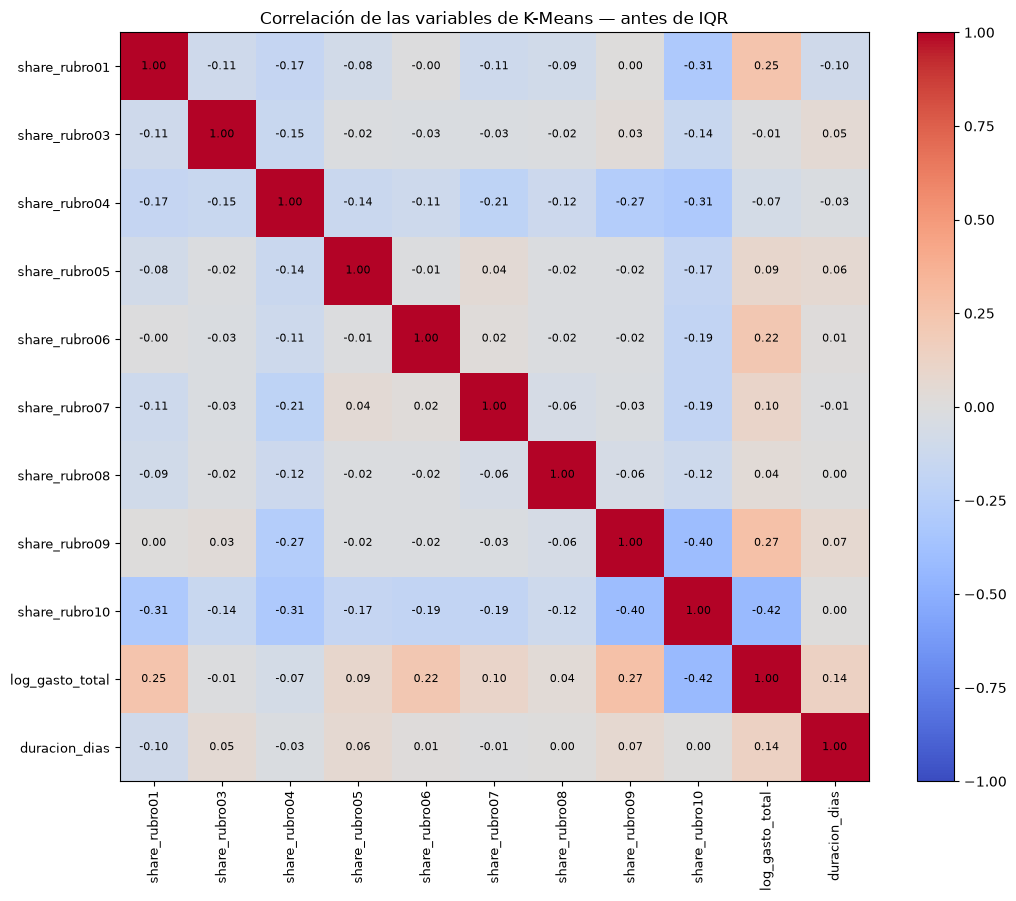

In [12]:
variable_grafico = None
if variable_grafico is not None:
    assert variable_grafico in columnas_numericas
    sns.histplot(data=df_trabajo, x=variable_grafico)
    plt.show()
    sns.boxplot(data=df_trabajo, x=variable_grafico)
    plt.show()

# Solo las variables que entrarán al modelo.
variables_correlacion = (
    [f"share_rubro{r:02d}" for r in RUBROS]
    + ["log_gasto_total", "duracion_dias"]
)
matriz_correlacion = df_trabajo[variables_correlacion].corr()
figura_correlacion, eje_correlacion = plt.subplots(figsize=(11, 9))
imagen_correlacion = eje_correlacion.imshow(
    matriz_correlacion, cmap="coolwarm", vmin=-1, vmax=1
)
eje_correlacion.set_xticks(range(len(variables_correlacion)))
eje_correlacion.set_yticks(range(len(variables_correlacion)))
eje_correlacion.set_xticklabels(variables_correlacion, rotation=90, fontsize=9)
eje_correlacion.set_yticklabels(variables_correlacion, fontsize=9)
for fila in range(len(variables_correlacion)):
    for columna in range(len(variables_correlacion)):
        eje_correlacion.text(
            columna, fila,
            f"{matriz_correlacion.iloc[fila, columna]:.2f}",
            ha="center", va="center", fontsize=8
        )
eje_correlacion.set_title("Correlación de las variables de K-Means — antes de IQR")
figura_correlacion.colorbar(imagen_correlacion, ax=eje_correlacion)
figura_correlacion.tight_layout()
display(figura_correlacion)
plt.close(figura_correlacion)


### 3.3 Candidatos atípicos mediante IQR

Se presenta el diagnóstico IQR de las cantidades disponibles. La exclusión posterior se limita a `gasto_total_viaje` y `duracion_dias`, las dos variables donde se observaron los extremos de la gráfica.

In [13]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

resumen_atipicos = []
for columna in columnas_numericas:
    candidatos = detect_outliers_iqr(df_trabajo, columna)
    resumen_atipicos.append({
        "variable": columna, "observados": int(df_trabajo[columna].notna().sum()),
        "candidatos_iqr": len(candidatos),
    })
resumen_atipicos = pd.DataFrame(resumen_atipicos, columns=[
    "variable", "observados", "candidatos_iqr"
])
display(resumen_atipicos)
if variable_grafico is not None:
    display(detect_outliers_iqr(df_trabajo, variable_grafico)[
        llave_final + [variable_grafico]
    ].head(20))

,variable,observados,candidatos_iqr
0,edad,4729,0
1,ingreso_mensual_hogar,4720,219
2,gasto_total_viaje,4729,438
3,paquete_monto,4729,135
4,paquete_n_personas,135,13
5,fex_trim,4729,724
6,rubro01_monto,4729,916
7,rubro03_monto,4729,997
8,rubro04_monto,4729,294
9,rubro05_monto,4729,871


### 3.4 Exclusión de atípicos de gasto y duración

Se utiliza la regla existente: límites **Q1 − 1,5 × IQR** y **Q3 + 1,5 × IQR**. Se retira una fila si queda fuera en gasto total o duración. Los límites se calculan una sola vez sobre la muestra previa; no se repite el recorte hasta eliminar todos los extremos.

Un valor extremo no demuestra un error de captura: esta exclusión delimita la muestra del ejercicio y deja fuera viajes de gasto o duración elevados. Los registros excluidos se conservan en `atipicos_excluidos`; los CSV originales permanecen intactos.

In [14]:
variables_iqr = ["gasto_total_viaje", "duracion_dias"]
limites_iqr = []
marcas_iqr = pd.DataFrame(index=df_trabajo.index)

for columna in variables_iqr:
    q1 = df_trabajo[columna].quantile(0.25)
    q3 = df_trabajo[columna].quantile(0.75)
    iqr = q3 - q1
    candidatos = detect_outliers_iqr(df_trabajo, columna)
    marcas_iqr[columna] = df_trabajo.index.isin(candidatos.index)
    limites_iqr.append({
        "Variable": columna,
        "Límite inferior": q1 - 1.5 * iqr,
        "Límite superior": q3 + 1.5 * iqr,
        "Filas marcadas": len(candidatos),
    })

excluir_iqr = marcas_iqr.any(axis=1)
indices_excluir = df_trabajo.index[excluir_iqr]
atipicos_excluidos = df_trabajo.loc[indices_excluir].copy()
df_preparado = df_trabajo.drop(index=indices_excluir).copy()
assert not df_preparado.duplicated(llave_final).any()

display(pd.DataFrame(limites_iqr))
display(pd.DataFrame({
    "Etapa": ["Antes de IQR", "Excluidas por IQR", "Después de IQR"],
    "Observaciones": [len(df_trabajo), len(atipicos_excluidos), len(df_preparado)],
}))
print("Porcentaje excluido:", round(100 * excluir_iqr.mean(), 2), "%")
display(pd.DataFrame({
    "Máximo antes": df_trabajo[variables_iqr].max(),
    "Máximo después": df_preparado[variables_iqr].max(),
}))

,Variable,Límite inferior,Límite superior,Filas marcadas
0,gasto_total_viaje,-1150000.0,2450000.0,438
1,duracion_dias,-4.0,12.0,396


,Etapa,Observaciones
0,Antes de IQR,4729
1,Excluidas por IQR,778
2,Después de IQR,3951


Porcentaje excluido: 16.45 %


,Máximo antes,Máximo después
gasto_total_viaje,25000000.0,2450000.0
duracion_dias,177.0,12.0


## Punto 4: Preparación, K-Means y comparación de clusters

### 4.1 Las 11 variables que recibe K-Means

- **Nueve proporciones:** `share_rubro01`, `share_rubro03`, `share_rubro04`, `share_rubro05`, `share_rubro06`, `share_rubro07`, `share_rubro08`, `share_rubro09` y `share_rubro10`.
- **Gasto:** `log_gasto_total = log(1 + gasto_total_viaje)`.
- **Duración:** `duracion_dias = fecha_fin_viaje − fecha_inicio_viaje`.

Cada proporción es el monto de su rubro dividido por `suma_rubros`: 0,25 representa el 25 % de la suma de los nueve rubros utilizados, **no necesariamente el 25 % del gasto total declarado**. Las proporciones suman 1 y tienen una dependencia entre sí.

El gasto bruto, edad, ingreso, noches por alojamiento, ciudad y sexo no se añaden como dimensiones del modelo. La tabla siguiente detalla el origen y la fórmula de cada entrada.

In [15]:
variables_modelado = (
    [f"share_rubro{r:02d}" for r in RUBROS]
    + ["log_gasto_total", "duracion_dias"]
)
X_previo = df_preparado.loc[:, variables_modelado].copy()
detalle_variables = pd.DataFrame({
    "Variable de entrada": variables_modelado,
    "Origen / fórmula": [
        f"TURISMO.P7581S{r}A1 / suma_rubros" for r in RUBROS
    ] + ["log(1 + TURISMO.P7578)", "fecha_fin_viaje - fecha_inicio_viaje"],
    "Unidad antes de escalar": ["Proporción entre 0 y 1"] * len(RUBROS)
        + ["Logaritmo del gasto en pesos más 1", "Días"],
})
display(detalle_variables)
display(pd.DataFrame({
    "tipo": X_previo.dtypes.astype(str),
    "faltantes": X_previo.isna().sum(),
    "valores_distintos": X_previo.nunique(),
}))
print("Variables seleccionadas:", len(variables_modelado))
assert not X_previo.isna().any().any(), "La matriz contiene faltantes."
assert np.isfinite(X_previo.to_numpy(dtype=float)).all(), "La matriz contiene valores no finitos."
print("Observaciones:", len(X_previo))
print("Estado: matriz sin faltantes ni valores no finitos, lista para K-Means.")

,Variable de entrada,Origen / fórmula,Unidad antes de escalar
0,share_rubro01,TURISMO.P7581S1A1 / suma_rubros,Proporción entre 0 y 1
1,share_rubro03,TURISMO.P7581S3A1 / suma_rubros,Proporción entre 0 y 1
2,share_rubro04,TURISMO.P7581S4A1 / suma_rubros,Proporción entre 0 y 1
3,share_rubro05,TURISMO.P7581S5A1 / suma_rubros,Proporción entre 0 y 1
4,share_rubro06,TURISMO.P7581S6A1 / suma_rubros,Proporción entre 0 y 1
5,share_rubro07,TURISMO.P7581S7A1 / suma_rubros,Proporción entre 0 y 1
6,share_rubro08,TURISMO.P7581S8A1 / suma_rubros,Proporción entre 0 y 1
7,share_rubro09,TURISMO.P7581S9A1 / suma_rubros,Proporción entre 0 y 1
8,share_rubro10,TURISMO.P7581S10A1 / suma_rubros,Proporción entre 0 y 1
9,log_gasto_total,log(1 + TURISMO.P7578),Logaritmo del gasto en pesos más 1


,tipo,faltantes,valores_distintos
share_rubro01,float64,0,314
share_rubro03,float64,0,266
share_rubro04,float64,0,540
share_rubro05,float64,0,191
share_rubro06,float64,0,179
share_rubro07,float64,0,222
share_rubro08,float64,0,141
share_rubro09,float64,0,172
share_rubro10,float64,0,535
log_gasto_total,float64,0,296


Variables seleccionadas: 11
Observaciones: 3951
Estado: matriz sin faltantes ni valores no finitos, lista para K-Means.


### 4.1.1 Visualización antes de K-Means, después del filtro IQR

Se representan dos proporciones continuas del gasto: rubros 04 y 10. Son dos entradas del modelo; no un resumen de sus once dimensiones. Se usa el mismo par antes y después de agrupar.

La duración tiene valores enteros y produce franjas verticales cuando se usa como eje. Cambiar de ejes evita esas franjas, pero no garantiza nubes separadas: los datos simulados fueron generados con grupos, mientras que aquí se explora una encuesta real. No se alteran observaciones para obtener una forma determinada.


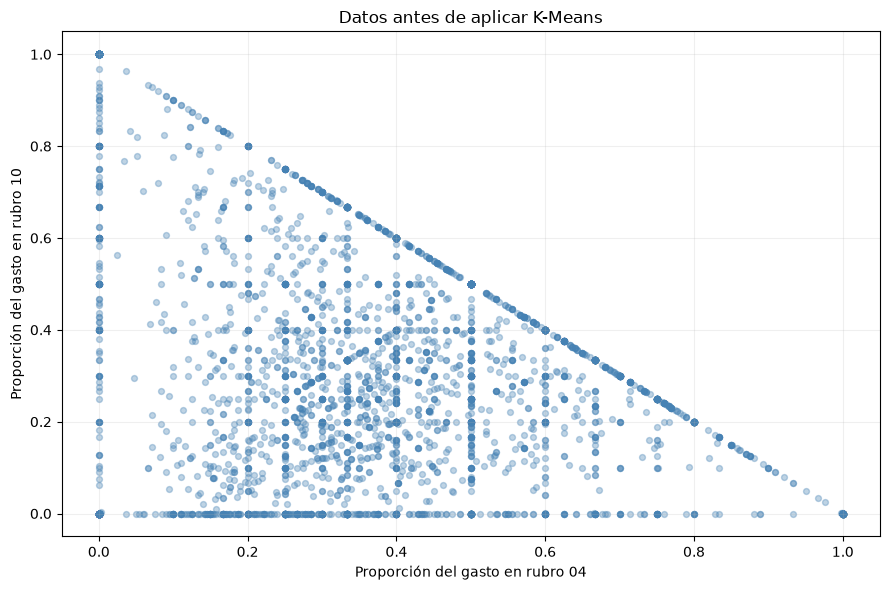

In [16]:
variables_visualizacion = ["share_rubro04", "share_rubro10"]
plt.figure(figsize=(9, 6))
plt.scatter(
    X_previo[variables_visualizacion[0]],
    X_previo[variables_visualizacion[1]],
    color="steelblue", s=18, alpha=0.35
)
plt.title("Datos antes de aplicar K-Means")
plt.xlabel("Proporción del gasto en rubro 04")
plt.ylabel("Proporción del gasto en rubro 10")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


### 4.1.2 Escalamiento, sin reducción de dimensionalidad

`StandardScaler` resta la media y divide por la desviación estándar de cada variable. Cambia las unidades, pero conserva las 11 columnas. La transformación logarítmica del gasto tampoco reduce el número de variables. [Referencia](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

In [17]:
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X_previo)

print("Antes de escalar:", X_previo.shape)
print("Después de escalar:", X_escalado.shape)
assert X_escalado.shape == X_previo.shape

pd.DataFrame(
    X_escalado, columns=variables_modelado, index=X_previo.index
).head()

Antes de escalar: (3951, 11)
Después de escalar: (3951, 11)


,share_rubro01,share_rubro03,share_rubro04,share_rubro05,share_rubro06,share_rubro07,share_rubro08,share_rubro09,share_rubro10,log_gasto_total,duracion_dias
19,-0.556151,-0.381878,0.114486,4.053965,-0.309030,-0.347283,-0.282262,-0.332913,-0.473388,0.242417,0.256820
26,0.814906,0.524006,-1.237075,-0.281683,0.589885,-0.347283,0.814228,-0.332913,0.400648,1.471070,-0.151344
27,1.020564,0.486260,-1.252718,-0.281683,0.552430,-0.347283,0.768541,-0.332913,0.333207,1.471070,-0.151344
30,1.289760,-0.381878,-0.664768,-0.281683,-0.309030,2.143844,-0.282262,-0.332913,-0.536947,0.629898,-0.151344
74,-0.556151,-0.381878,0.977983,-0.281683,-0.309030,-0.347283,-0.282262,2.077309,-1.217937,0.242417,-0.151344


### 4.1.3 Método del codo: K de 1 a 50

Se conserva el rango ampliado. Se busca un cambio de pendiente: a partir de cierto K, los grupos adicionales reducen menos la inercia.

**Elección manual: K=9**, tomando como referencia la reducción relativa al pasar de 8 a 9 grupos. Un porcentaje mayor no demuestra por sí solo que K sea óptimo: también se compara con las mejoras vecinas y con la forma de la curva. No se selecciona K automáticamente.

La tabla muestra el porcentaje calculado en cada ejecución, no un valor fijo. Se utiliza la imputación con cero documentada en el Punto 2; K=9 permanece como elección manual.


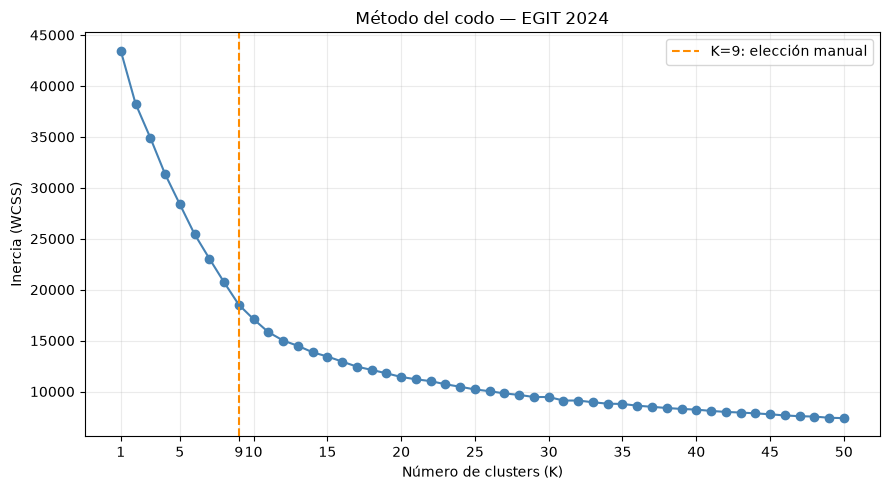

,K,Inercia (WCSS),Reducción de inercia respecto a K anterior (%)
0,1,43461.00,NaN
1,2,38269.81,11.94
2,3,34922.67,8.75
3,4,31358.68,10.21
4,5,28390.89,9.46
5,6,25453.06,10.35
6,7,23059.37,9.40
7,8,20729.72,10.10
8,9,18518.78,10.67
9,10,17101.99,7.65


In [18]:
k_elegido = 9  # Elección manual; no calculada por otro algoritmo.
valores_k = range(1, 51)
inercias = []

for numero_clusters in valores_k:
    modelo = KMeans(
        n_clusters=numero_clusters,
        random_state=42,
        n_init=10
    )
    modelo.fit(X_escalado)
    inercias.append(modelo.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(valores_k, inercias, marker="o", color="steelblue")
plt.xticks([1, 5, 9, 10, 15, 20, 25, 30, 35, 40, 45, 50])
plt.axvline(k_elegido, color="darkorange", linestyle="--", label="K=9: elección manual")
plt.legend()
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del codo — EGIT 2024")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

tabla_codo = pd.DataFrame({"K": list(valores_k), "Inercia (WCSS)": inercias})
tabla_codo["Reducción de inercia respecto a K anterior (%)"] = (
    -tabla_codo["Inercia (WCSS)"].pct_change() * 100
)
display(tabla_codo.round(2))

### 4.1.4 Entrenamiento de K-Means con nueve grupos

Se entrena el modelo con las 11 variables estandarizadas y **K=9**, elegido manualmente. `fit_predict()` ajusta los centroides y asigna cada observación al grupo más cercano. Se suma 1 a las etiquetas para presentar los clusters del 1 al 9; los números identifican grupos, no un orden de importancia.


In [19]:
kmeans = KMeans(n_clusters=k_elegido, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_escalado)
df_preparado["Cluster"] = pd.Series(clusters + 1, index=X_previo.index)

assert df_preparado["Cluster"].notna().all()
assert df_preparado["Cluster"].nunique() == k_elegido
print("Observaciones agrupadas:", len(df_preparado))
print("Número de clusters:", df_preparado["Cluster"].nunique())


Observaciones agrupadas: 3951
Número de clusters: 9


### 4.1.5 Tamaño de los clusters

Se muestra cuántos registros contiene cada grupo y qué porcentaje representa sobre la muestra modelada.


In [20]:
observaciones_cluster = df_preparado["Cluster"].value_counts().sort_index()
porcentaje_cluster = (
    df_preparado["Cluster"].value_counts(normalize=True).sort_index() * 100
)
tamano_clusters = pd.DataFrame({
    "Observaciones": observaciones_cluster,
    "Porcentaje (%)": porcentaje_cluster.round(2)
})
tamano_clusters.index.name = "Cluster"
display(tamano_clusters)


,Observaciones,Porcentaje (%)
Cluster,,
1,241,6.10
2,682,17.26
3,126,3.19
4,381,9.64
5,1300,32.90
6,203,5.14
7,183,4.63
8,752,19.03
9,83,2.10


### 4.1.6 Información del modelo y centroides

La inercia (WCSS) mide la suma de distancias cuadradas a los centroides en el espacio escalado. Se muestran las iteraciones realizadas y los centroides estandarizados.


In [21]:
print("Inercia (WCSS):", round(kmeans.inertia_, 2))
print("Iteraciones realizadas:", kmeans.n_iter_)
centroides_escalados = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=variables_modelado,
    index=pd.Index(range(1, k_elegido + 1), name="Cluster")
)
display(centroides_escalados.round(2))


Inercia (WCSS): 18518.78
Iteraciones realizadas: 23


,share_rubro01,share_rubro03,share_rubro04,share_rubro05,share_rubro06,share_rubro07,share_rubro08,share_rubro09,share_rubro10,log_gasto_total,duracion_dias
Cluster,,,,,,,,,,,
1,-0.20,-0.14,-0.18,-0.04,3.15,-0.01,-0.10,-0.20,-0.41,0.50,0.10
2,-0.46,-0.12,-0.88,-0.22,-0.29,-0.28,-0.26,-0.31,1.64,-0.93,-0.10
3,-0.47,4.14,-0.18,-0.15,-0.21,-0.08,-0.25,-0.29,-0.62,-0.21,0.23
4,0.04,0.14,-0.66,-0.04,-0.13,-0.02,-0.14,2.79,-1.12,0.85,0.40
5,-0.53,-0.18,0.99,-0.11,-0.24,-0.19,-0.21,-0.33,-0.00,-0.12,0.01
6,-0.42,-0.06,-0.34,-0.06,-0.21,-0.24,3.74,-0.30,-0.39,0.08,0.04
7,-0.49,-0.20,-0.64,0.03,-0.16,3.55,-0.24,-0.32,-0.38,0.08,0.05
8,1.74,-0.21,-0.17,-0.14,-0.09,-0.19,-0.18,-0.27,-0.42,0.44,-0.27
9,-0.49,-0.16,-0.66,5.34,-0.29,0.10,-0.28,-0.23,-0.63,0.13,0.46


Al deshacer el escalamiento, los centroides vuelven a las unidades de entrada: proporciones, días y logaritmo del gasto. **El gasto sigue en logaritmo**, no en pesos; el gasto promedio en pesos se consulta en la tabla de promedios.


In [22]:
centroides_originales = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=variables_modelado,
    index=pd.Index(range(1, k_elegido + 1), name="Cluster")
)
display(centroides_originales.round(2))


,share_rubro01,share_rubro03,share_rubro04,share_rubro05,share_rubro06,share_rubro07,share_rubro08,share_rubro09,share_rubro10,log_gasto_total,duracion_dias
Cluster,,,,,,,,,,,
1,0.06,0.02,0.33,0.02,0.27,0.04,0.02,0.02,0.22,13.46,3.61
2,0.02,0.03,0.17,0.01,0.00,0.01,0.00,0.00,0.77,11.63,3.13
3,0.01,0.43,0.33,0.01,0.01,0.03,0.00,0.01,0.16,12.55,3.94
4,0.09,0.05,0.22,0.02,0.01,0.04,0.01,0.52,0.03,13.90,4.35
5,0.00,0.02,0.60,0.02,0.01,0.02,0.01,0.00,0.33,12.65,3.39
6,0.02,0.03,0.30,0.02,0.01,0.01,0.38,0.00,0.22,12.92,3.47
7,0.01,0.02,0.22,0.03,0.01,0.48,0.00,0.00,0.23,12.91,3.49
8,0.36,0.02,0.33,0.01,0.02,0.02,0.01,0.01,0.22,13.38,2.71
9,0.01,0.02,0.22,0.52,0.00,0.05,0.00,0.02,0.16,12.98,4.51


### 4.1.7 Visualización de clusters y centroides

La primera gráfica muestra las mismas dos proporciones del apartado 4.1.1, ahora estandarizadas y coloreadas por grupo. Las X son las dos coordenadas correspondientes de los centroides. **La superposición en dos ejes no permite juzgar por sí sola la separación en once dimensiones.** No se aplica PCA ni se modifica la muestra para separar visualmente los puntos.

El mapa de perfiles muestra los nueve centroides en las **once variables estandarizadas**: rojo indica valores por encima de la media de la muestra y azul, por debajo. Permite ver diferencias que no aparecen en el scatter; no es una matriz de correlación ni una prueba de calidad del agrupamiento.


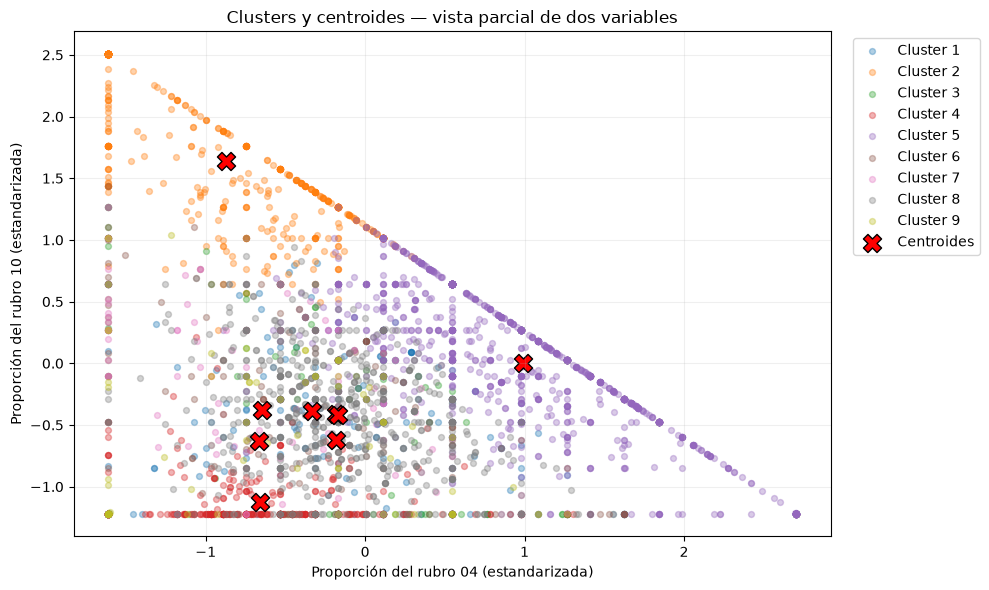

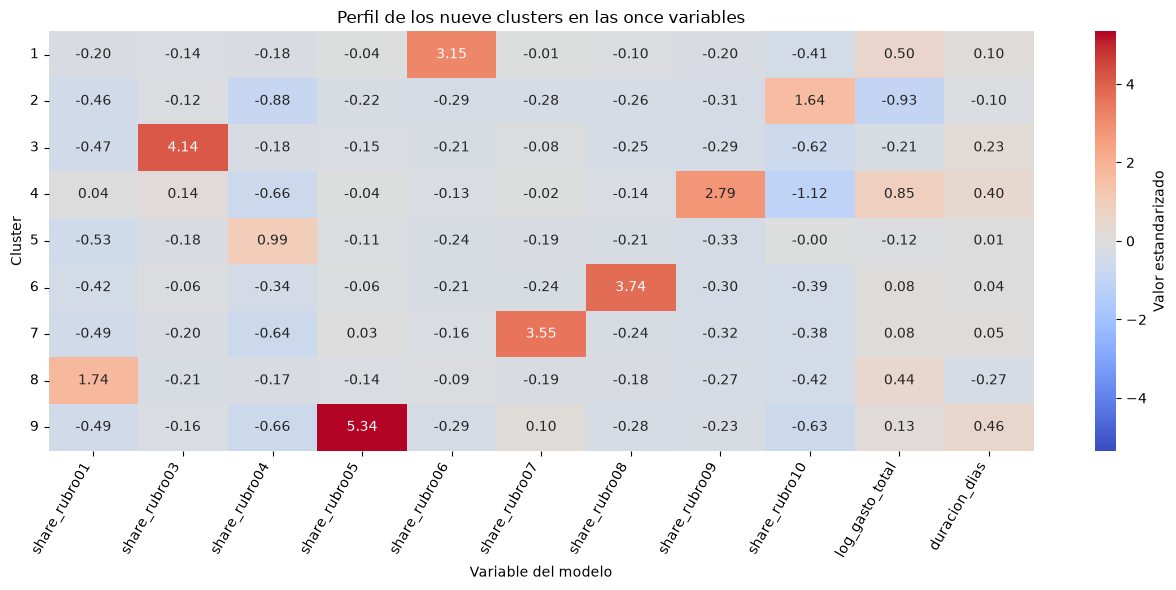

In [23]:
# Vista parcial: mismas dos variables del gráfico inicial, estandarizadas.
pos_x = variables_modelado.index(variables_visualizacion[0])
pos_y = variables_modelado.index(variables_visualizacion[1])
plt.figure(figsize=(10, 6))
colores = plt.get_cmap("tab10")
for numero_cluster in range(1, k_elegido + 1):
    mascara = clusters == numero_cluster - 1
    plt.scatter(
        X_escalado[mascara, pos_x], X_escalado[mascara, pos_y],
        color=colores(numero_cluster - 1), s=18, alpha=0.35,
        label=f"Cluster {numero_cluster}"
    )
plt.scatter(
    kmeans.cluster_centers_[:, pos_x], kmeans.cluster_centers_[:, pos_y],
    marker="X", s=170, color="red", edgecolors="black", label="Centroides"
)
plt.title("Clusters y centroides — vista parcial de dos variables")
plt.xlabel("Proporción del rubro 04 (estandarizada)")
plt.ylabel("Proporción del rubro 10 (estandarizada)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# Perfil completo: se muestran las once coordenadas de cada centroide.
plt.figure(figsize=(13, 6))
limite_color = float(centroides_escalados.abs().max().max())
sns.heatmap(
    centroides_escalados, annot=True, fmt=".2f", cmap="coolwarm",
    center=0, vmin=-limite_color, vmax=limite_color,
    cbar_kws={"label": "Valor estandarizado"}
)
plt.title("Perfil de los nueve clusters en las once variables")
plt.xlabel("Variable del modelo")
plt.ylabel("Cluster")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 4.1.8 Promedios por cluster

Cada fila resume un grupo. Primero se comparan gasto total en pesos y duración en días; después, las proporciones medias de los nueve rubros, expresadas como porcentajes. Estos últimos son promedios de proporciones individuales, no porcentajes calculados sobre el gasto acumulado del grupo. Las tablas permiten describir los perfiles durante la exposición.


In [24]:
promedios_clusters = df_preparado.groupby("Cluster")[
    ["gasto_total_viaje", "duracion_dias"]
].mean()
print("Gasto y duración promedio por cluster")
display(promedios_clusters.round(2))

proporciones_clusters = df_preparado.groupby("Cluster")[
    [f"share_rubro{r:02d}" for r in RUBROS]
].mean() * 100
print("Proporciones promedio por rubro (%)")
display(proporciones_clusters.round(2))


Gasto y duración promedio por cluster


,gasto_total_viaje,duracion_dias
Cluster,,
1,894655.60,3.61
2,234814.70,3.13
3,395484.13,3.94
4,1231682.41,4.35
5,445558.92,3.39
6,595921.67,3.47
7,601342.90,3.49
8,844277.39,2.71
9,657192.77,4.51


Proporciones promedio por rubro (%)


,share_rubro01,share_rubro03,share_rubro04,share_rubro05,share_rubro06,share_rubro07,share_rubro08,share_rubro09,share_rubro10
Cluster,,,,,,,,,
1,5.69,2.32,33.16,2.27,26.73,4.08,1.77,2.22,21.76
2,1.51,2.51,17.07,0.60,0.13,0.78,0.25,0.37,76.77
3,1.31,43.40,33.13,1.21,0.77,3.28,0.28,0.64,15.99
4,9.48,5.04,22.10,2.25,1.37,3.95,1.37,51.82,2.62
5,0.41,1.89,60.21,1.60,0.51,1.92,0.68,0.09,32.68
6,2.23,3.10,29.58,2.03,0.75,1.32,38.29,0.47,22.22
7,1.00,1.77,22.41,2.85,1.12,47.75,0.40,0.16,22.53
8,36.47,1.64,33.41,1.29,1.68,1.87,0.98,1.10,21.56
9,0.98,2.11,21.97,51.88,0.12,5.46,0.00,1.69,15.78
